In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import mendeleev as mdl

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)
plt.rcParams.update({'font.size': 10})

In [66]:
print(mdl.element('Fe').density)
print(10**(-9)/(1.602*10**(-19)))

7.87
6242197253.433209


In [67]:
def Phi(beam_current, charge_number):
    # print(beam_current/(charge_number*(1.602*10**(-19))))
    return beam_current/(charge_number*(1.602*10**(-19)))

def eta(density, molar_mass):
    # print((density*6.022*10**(23))/(molar_mass))
    return (density*6.022*10**(23))/(molar_mass)

def Luminosity(flux, target_number_density, length):
    return flux * target_number_density * length

def total_rate(Luminosity, crosssection):
    return Luminosity * crosssection

def rate_on_detector(total_rate, active_area, placement_radius):
    return total_rate * (active_area)/(4*np.pi*(placement_radius)**2)

In [68]:
L = Luminosity(flux=Phi(beam_current=10**(-9), charge_number=1),target_number_density=eta(density=mdl.element('Fe').density, molar_mass=mdl.element('Fe').atomic_weight), length=5*10**(-3))
print(f'Luminosity L =' + ' {:0.3e}'.format(L) + ' 1/cm²s')


Luminosity L = 2.649e+30 1/cm²s


In [69]:
sigma = [[429,408,424],['L', 'ECPSSR', 'Reference']]

In [70]:
for i in range(0,len(sigma[0])):
    dNdt_total = total_rate(Luminosity=L, crosssection=float(sigma[0][i])*10**(-24))
    print(f'Total rate for N_{sigma[1][i]} = ' + '{:0.3e}'.format(dNdt_total/1000000), 'MHz')
    
    dNdt_det = rate_on_detector(total_rate=dNdt_total, active_area=70, placement_radius=150)
    print(f'Rate on Detector for N_{sigma[1][i]} = ' + '{:0.3e}'.format(dNdt_det/1000), 'kHz')
    print('-----------------------------------------------------------------')

Total rate for N_L = 1.136e+03 MHz
Rate on Detector for N_L = 2.813e+02 kHz
-----------------------------------------------------------------
Total rate for N_ECPSSR = 1.081e+03 MHz
Rate on Detector for N_ECPSSR = 2.675e+02 kHz
-----------------------------------------------------------------
Total rate for N_Reference = 1.123e+03 MHz
Rate on Detector for N_Reference = 2.780e+02 kHz
-----------------------------------------------------------------


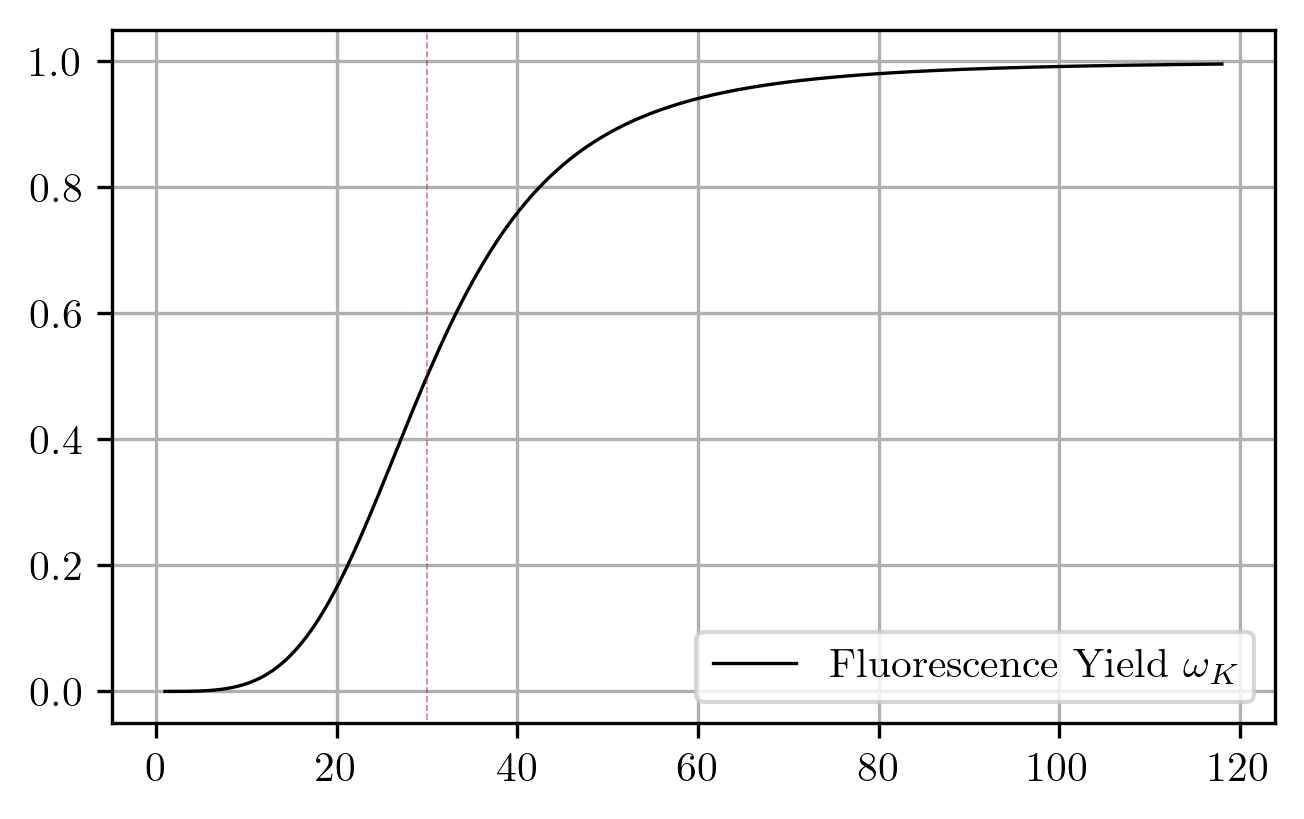